# D50 and Shear Stress Analysis


In [33]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# For Excel file reading (install with: pip install openpyxl)
try:
    import openpyxl
except ImportError:
    print("⚠️  openpyxl not installed. Install with: pip install openpyxl")

# Set plotting style
plt.style.use('default')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 12

print("✅ Libraries imported")

✅ Libraries imported


In [34]:
# Excel file with D50 measurements
EXCEL_D50_PATH = "/Users/BrookeMac/Library/CloudStorage/OneDrive-UW/Hydrology/D50.xlsx"

# Shear stress parameters (optional - set to None to skip actual shear stress calculation)
SLOPE = None  # Channel slope (m/m) - set to None if not available
DEPTH = None  # Channel depth (m) - set to None if not available

# Physical constants
RHO_WATER = 1000.0  # kg/m³ (water density)
RHO_SEDIMENT = 2650.0  # kg/m³ (sediment density)
GRAVITY = 9.81  # m/s²
FRICTION_FACTOR = 0.03  # Friction factor for gravel-bed rivers

# Output paths
OUTPUT_DIR = Path("data")
OUTPUT_DIR.mkdir(exist_ok=True)
SHEAR_STRESS_OUTPUT = OUTPUT_DIR / "nooksack_shear_stress_analysis.csv"
PLOT_OUTPUT = OUTPUT_DIR / "nooksack_d50_shear_stress_plot.png"

print("✅ Configuration loaded")

✅ Configuration loaded


In [ ]:
# Load Excel file
print(f"Loading D50 measurements from: {EXCEL_D50_PATH}")
df = pd.read_excel(EXCEL_D50_PATH, sheet_name="D50")

print(f"✅ Loaded {len(df)} rows")
print(f"   Columns: {list(df.columns)}")
print(f"\nFirst few rows (before processing merged cells):")
print(df.head(10))

# Find RM and D50 columns first
rm_col = None
d50_col = None

for col in df.columns:
    col_lower = col.lower()
    if 'rm' in col_lower or 'river' in col_lower or 'mile' in col_lower:
        rm_col = col
    if 'd50' in col_lower or 'd_50' in col_lower:
        d50_col = col

if rm_col is None:
    raise ValueError("Could not find River Mile column. Please check column names.")
if d50_col is None:
    raise ValueError("Could not find D50 column. Please check column names.")

print(f"\n✅ Using columns: '{rm_col}' (river mile), '{d50_col}' (D50)")

# Handle merged cells - forward fill RM and Bank columns
# Excel merges cells, so some rows have NaN for RM/Bank
df[rm_col] = df[rm_col].ffill()  # Forward fill to handle merged cells
if 'Bank' in df.columns:
    df['Bank'] = df['Bank'].ffill()  # Forward fill Bank column too

print(f"\nAfter handling merged cells:")
print(df.head(10))

# Function to extract D50 in mm from various formats
def extract_d50_mm(value):
    """Extract D50 in mm from formats like '0.03 (0.7)' or numeric values"""
    if pd.isna(value):
        return np.nan
    value_str = str(value)
    # Check if it's in format "inches (mm)"
    if '(' in value_str and ')' in value_str:
        # Extract the value in parentheses (mm)
        mm_part = value_str.split('(')[1].split(')')[0]
        try:
            return float(mm_part)
        except:
            return np.nan
    else:
        # Assume it's numeric - if < 1, might be inches, convert to mm
        try:
            val = float(value_str)
            if val < 1:
                return val * 25.4  # Convert inches to mm
            return val
        except:
            return np.nan

# Process D50 data
df_clean = pd.DataFrame({
    'river_mile': pd.to_numeric(df[rm_col], errors='coerce'),
    'd50_mm': df[d50_col].apply(extract_d50_mm)
})

# Remove rows with missing values
df_clean = df_clean.dropna()

# If multiple measurements per river mile, average them
df_clean = df_clean.groupby('river_mile')['d50_mm'].mean().reset_index()
df_clean = df_clean.sort_values('river_mile').reset_index(drop=True)

# Convert to inches
df_clean['d50_inches'] = df_clean['d50_mm'] / 25.4


Loading D50 measurements from: /Users/BrookeMac/Library/CloudStorage/OneDrive-UW/Hydrology/D50.xlsx
✅ Loaded 96 rows
   Columns: ['RM', 'Bank', 'Location', 'Type', 'D50', 'D84']

First few rows (before processing merged cells):
    RM   Bank      Location  Type          D50           D84
0  1.6  right           bar  bulk  0.03  (0.7)    0.1  (2.5)
1  3.8   left      bar, u/s  bulk   0.2  (5.2)  0.57  (14.6)
2  NaN    NaN      bar, d/s  bulk  0.11  (2.8)   0.18  (4.6)
3  5.8   left      bar, u/s  bulk  0.03  (0.9)   0.25  (6.5)
4  NaN    NaN  channel, u/s  bulk  0.14  (3.5)  0.48  (12.2)
5  NaN    NaN      bar, d/s  bulk  0.08  (2.1)  0.49  (12.4)
6  NaN    NaN  channel, d/s  bulk  0.06  (1.4)  0.51  (12.9)
7  7.2  right      bar, u/s  bulk  0.18  (4.5)  0.65  (16.5)
8  NaN    NaN  channel, mid  bulk  0.05  (1.2)  0.47  (11.9)
9  NaN    NaN      bar, d/s  bulk  0.04  (1.1)   0.14  (3.5)

✅ Using columns: 'RM' (river mile), 'D50' (D50)

After handling merged cells:
    RM   Bank      Loc

## Step 2: Calculate Shear Stress


## Quick Scatter Plot of All Data


📊 Total measurements in dataset: 75
   Unique river mile locations: 20


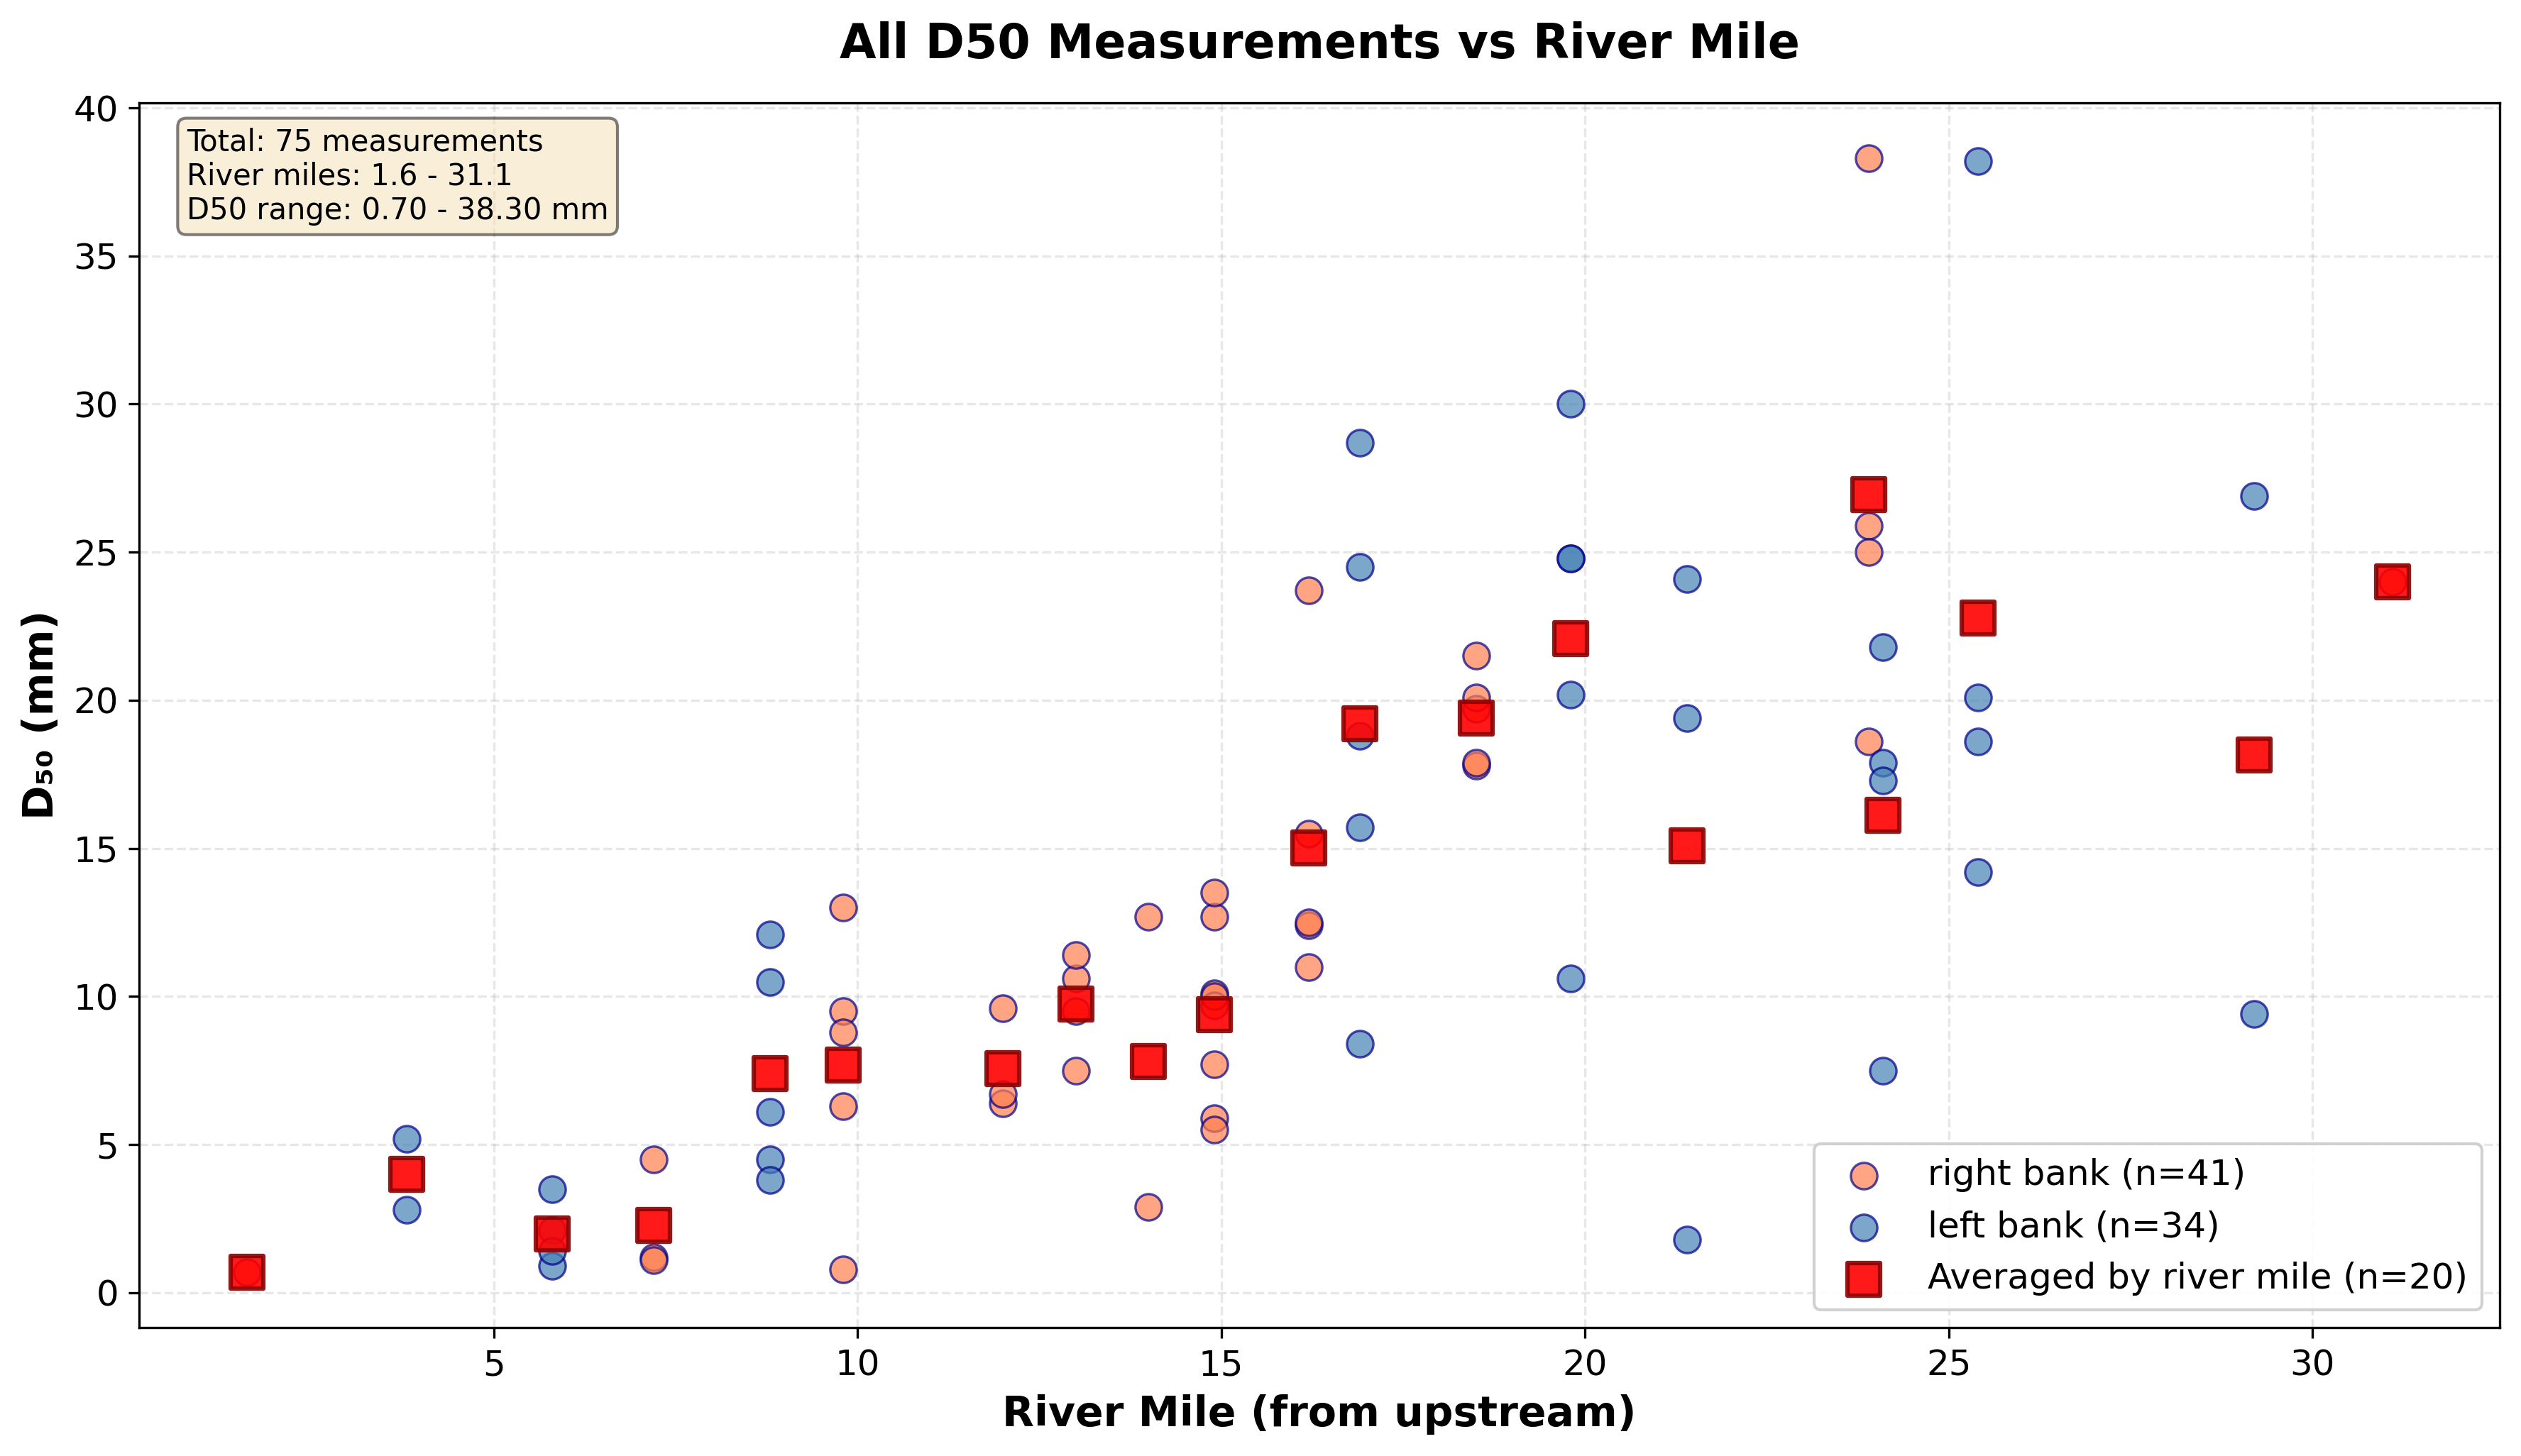

In [36]:
# Create scatter plot of ALL raw D50 measurements (no averaging)
# Process all rows from the original dataframe
# Make sure RM is forward-filled (handles merged cells)
df_all = df.copy()
if rm_col in df_all.columns:
    df_all[rm_col] = df_all[rm_col].ffill()  # Ensure RM is filled

df_all = pd.DataFrame({
    'river_mile': pd.to_numeric(df_all[rm_col], errors='coerce'),
    'd50_mm': df_all[d50_col].apply(extract_d50_mm),
    'bank': df_all.get('Bank', None),
    'location': df_all.get('Location', None)
})

# Remove rows with missing D50 or river mile
df_all = df_all.dropna(subset=['river_mile', 'd50_mm'])

print(f"📊 Total measurements in dataset: {len(df_all)}")
print(f"   Unique river mile locations: {df_all['river_mile'].nunique()}")

# Create scatter plot
fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

# Scatter ALL individual data points
# Color by bank if available
if 'bank' in df_all.columns and df_all['bank'].notna().any():
    banks = df_all['bank'].dropna().unique()
    colors = {'left': 'steelblue', 'right': 'coral', 'right bank': 'coral', 'left bank': 'steelblue'}
    for bank in banks:
        bank_data = df_all[df_all['bank'] == bank]
        bank_color = colors.get(bank.lower(), 'steelblue')
        ax.scatter(bank_data['river_mile'], bank_data['d50_mm'], 
                  s=80, alpha=0.7, color=bank_color, edgecolors='darkblue', linewidth=0.8,
                  label=f'{bank} bank (n={len(bank_data)})', zorder=3)
else:
    ax.scatter(df_all['river_mile'], df_all['d50_mm'], 
              s=80, alpha=0.7, color='steelblue', edgecolors='darkblue', linewidth=0.8,
              label=f'All D50 measurements (n={len(df_all)})', zorder=3)

# Optionally overlay averaged points for reference
if len(df_all) != len(df_clean):
    ax.scatter(df_clean['river_mile'], df_clean['d50_mm'], 
              s=120, alpha=0.9, color='red', marker='s', edgecolors='darkred', linewidth=1.5,
              label=f'Averaged by river mile (n={len(df_clean)})', zorder=4)

ax.set_xlabel('River Mile (from upstream)', fontsize=14, fontweight='bold')
ax.set_ylabel('D₅₀ (mm)', fontsize=14, fontweight='bold')
ax.set_title('All D50 Measurements vs River Mile', fontsize=16, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, linestyle='--', zorder=1)
ax.legend(loc='best', fontsize=12, framealpha=0.9)
ax.tick_params(axis='both', which='major', labelsize=12)

# Add some statistics as text
stats_text = f'Total: {len(df_all)} measurements\n'
stats_text += f'River miles: {df_all["river_mile"].min():.1f} - {df_all["river_mile"].max():.1f}\n'
stats_text += f'D50 range: {df_all["d50_mm"].min():.2f} - {df_all["d50_mm"].max():.2f} mm'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


In [39]:
def calculate_critical_shear_stress(d50_mm: float) -> float:
    """Calculate critical shear stress: τ_cr = (1/2) × f_w × (ρ_s - ρ_w) × g × d_50"""
    d50_m = d50_mm / 1000.0  # Convert mm to m
    tau_cr = FRICTION_FACTOR * (RHO_SEDIMENT - RHO_WATER) * GRAVITY * d50_m
    return max(0.0, tau_cr)

def calculate_actual_shear_stress(depth: float, slope: float) -> float:
    """Calculate actual shear stress: τ = ρ_w × g × R × S"""
    hydraulic_radius = depth  # For wide channels, R ≈ depth
    tau = RHO_WATER * GRAVITY * hydraulic_radius * slope
    return max(0.0, tau)

# Calculate critical shear stress (always possible with D50)
df_clean['tau_cr_pa'] = df_clean['d50_mm'].apply(calculate_critical_shear_stress)
df_clean['tau_cr_dynes_per_cm2'] = df_clean['tau_cr_pa'] * 10.0  # Convert to dynes/cm²

print(f"\n✅ Critical shear stress calculated")
print(f"   Range: {df_clean['tau_cr_pa'].min():.2f} - {df_clean['tau_cr_pa'].max():.2f} Pa")
print(f"   Mean: {df_clean['tau_cr_pa'].mean():.2f} Pa")

# Calculate actual shear stress if depth and slope are provided
if SLOPE is not None and DEPTH is not None:
    df_clean['tau_actual_pa'] = calculate_actual_shear_stress(DEPTH, SLOPE)
    df_clean['tau_actual_dynes_per_cm2'] = df_clean['tau_actual_pa'] * 10.0
    
    # Calculate mobility ratio
    df_clean['tau_ratio'] = df_clean['tau_actual_pa'] / df_clean['tau_cr_pa']
    df_clean['tau_ratio'] = df_clean['tau_ratio'].replace([np.inf, -np.inf], np.nan)
    
    print(f"✅ Actual shear stress calculated")
    print(f"   Value: {df_clean['tau_actual_pa'].iloc[0]:.2f} Pa (constant)")
    print(f"   Mobility ratio (τ/τ_cr): {df_clean['tau_ratio'].mean():.3f}")
    print(f"   Points with τ/τ_cr > 1 (motion expected): {(df_clean['tau_ratio'] > 1).sum()}")
else:
    print("⚠️  Actual shear stress not calculated (slope and/or depth not provided)")

# Save results
df_clean.to_csv(SHEAR_STRESS_OUTPUT, index=False)
print(f"\n💾 Shear stress data saved to: {SHEAR_STRESS_OUTPUT}")



✅ Critical shear stress calculated
   Range: 0.34 - 13.09 Pa
   Mean: 6.25 Pa
⚠️  Actual shear stress not calculated (slope and/or depth not provided)

💾 Shear stress data saved to: data/nooksack_shear_stress_analysis.csv


## Step 3: Visualize Results


📊 Plot saved to: data/nooksack_d50_shear_stress_plot.png


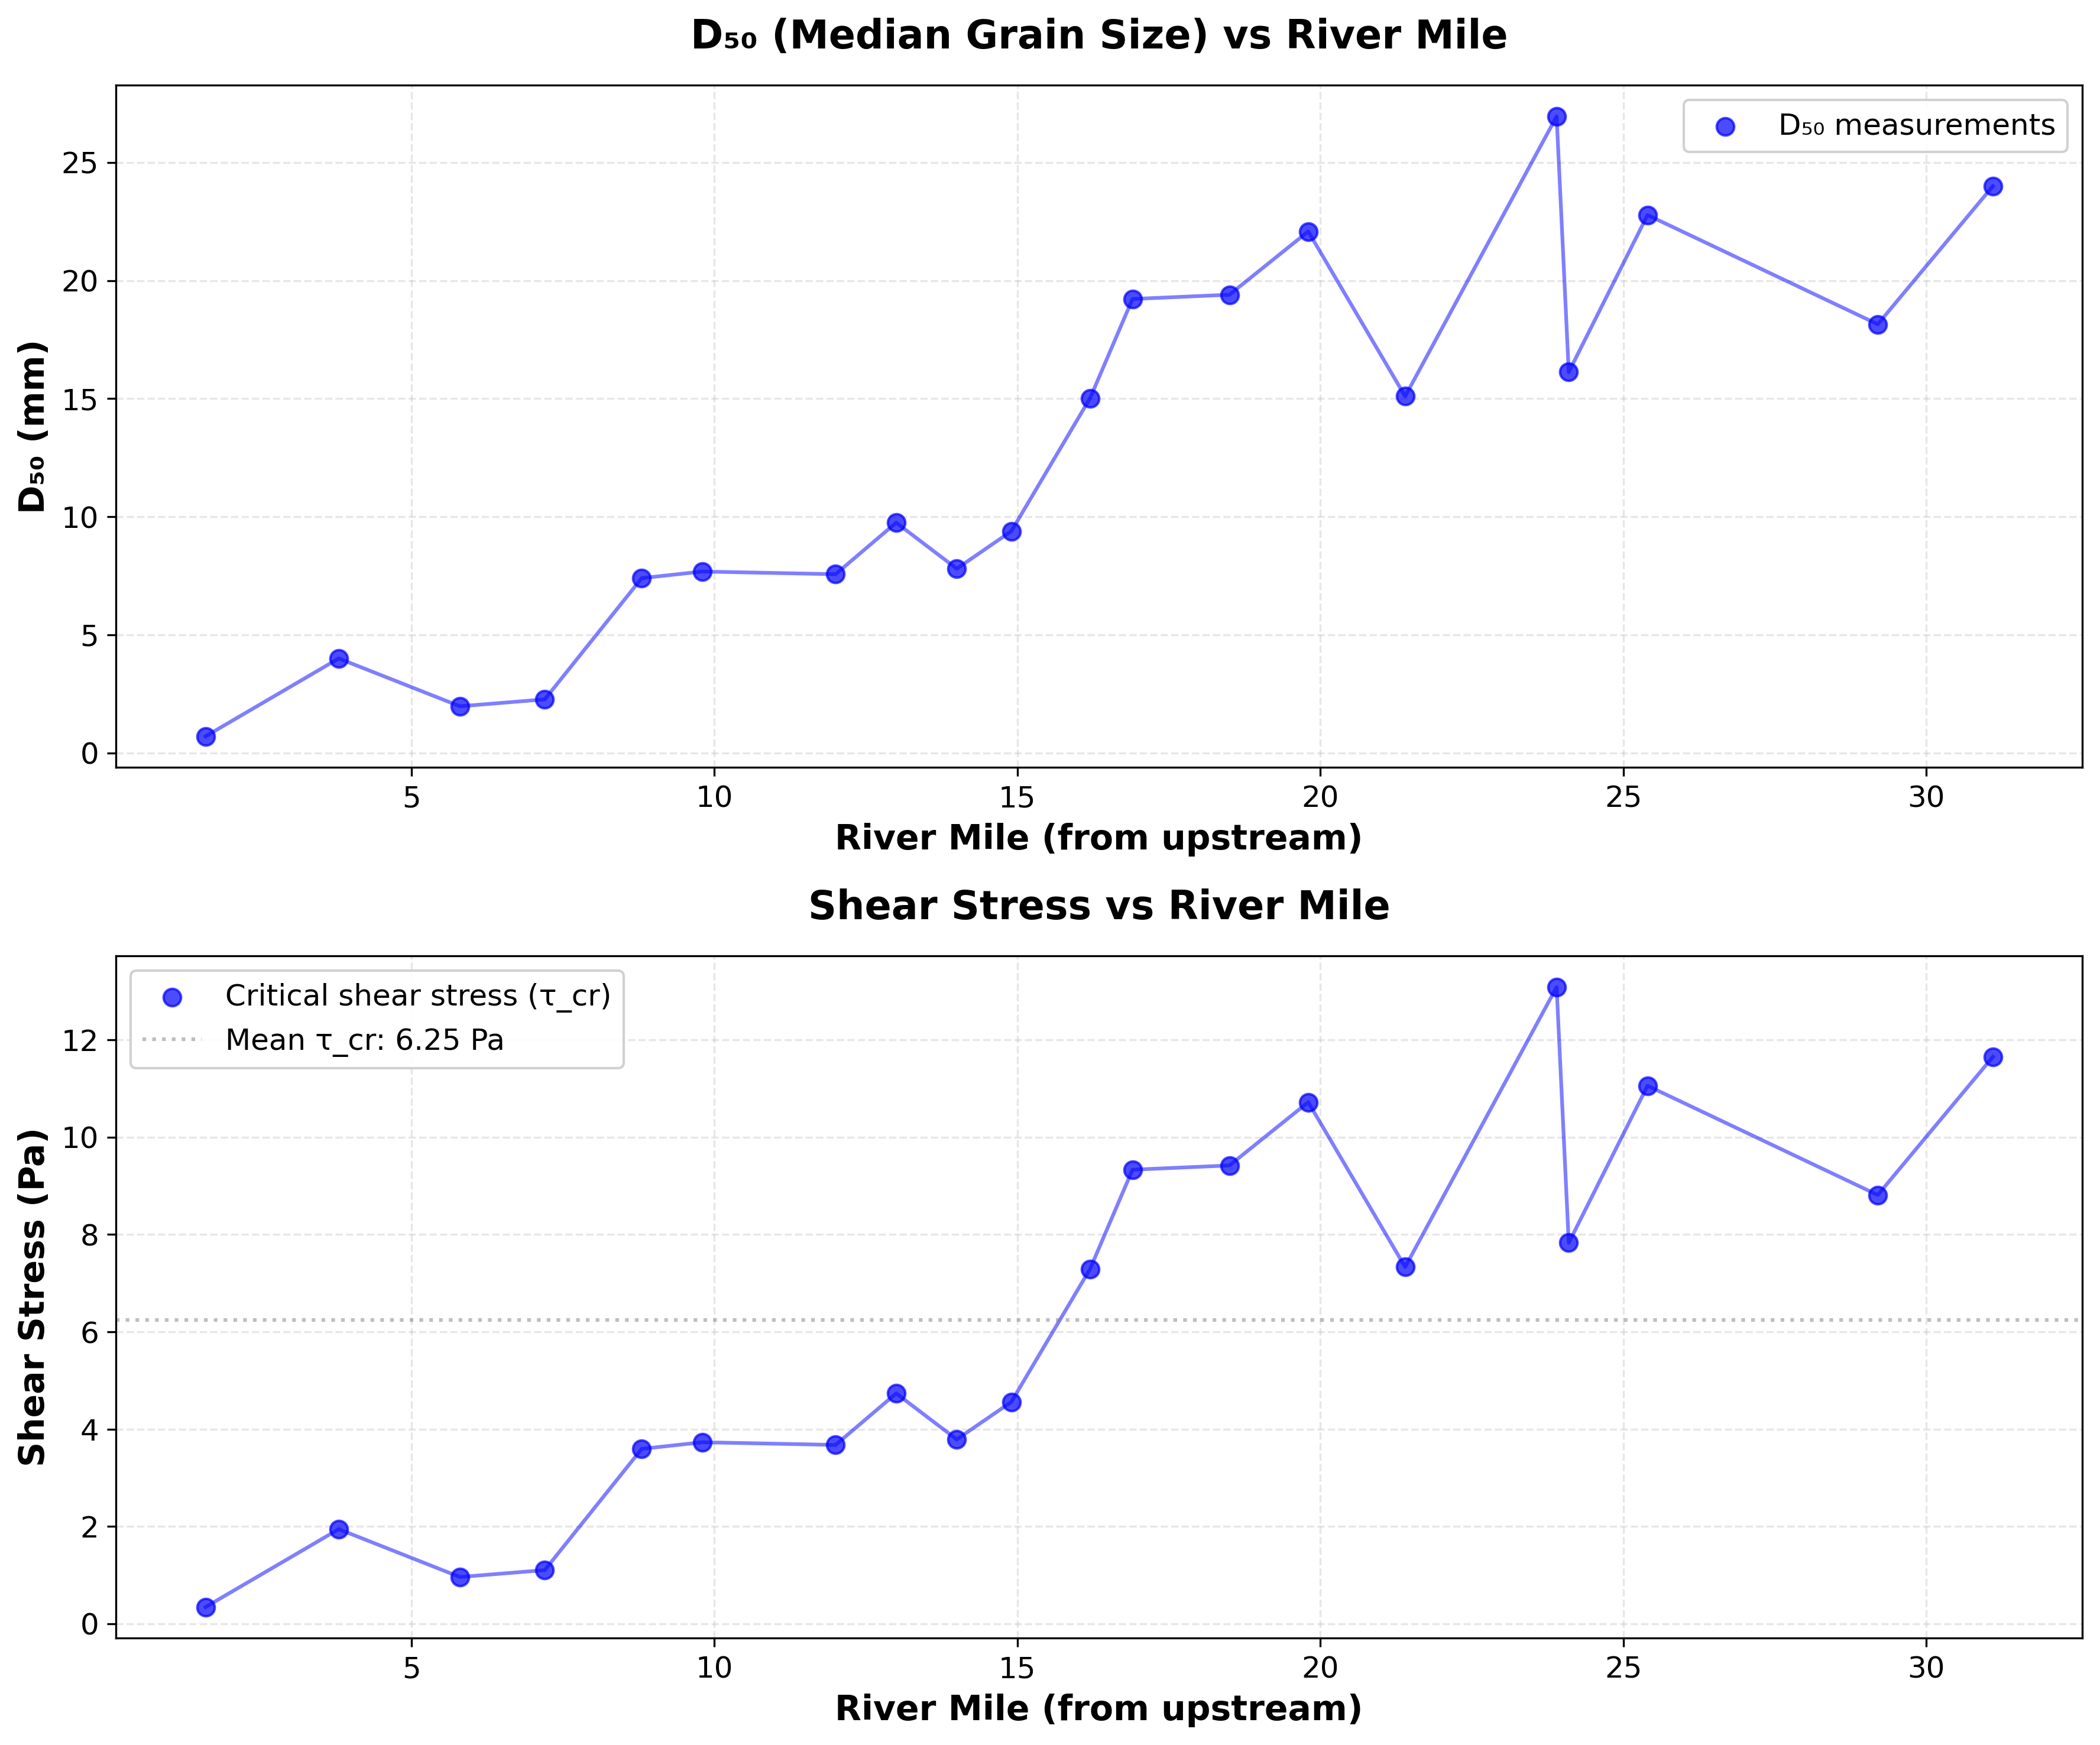

In [40]:
# Filter out zero D50 values for better visualization
valid_mask = df_clean['d50_mm'] > 0

# Create figure with subplots
if SLOPE is not None and DEPTH is not None:
    fig, axes = plt.subplots(3, 1, figsize=(12, 12), dpi=300)
else:
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), dpi=300)

# Plot 1: D50 vs River Mile
ax1 = axes[0]
ax1.scatter(df_clean['river_mile'], df_clean['d50_mm'], 
           s=50, alpha=0.7, color='blue', zorder=3, label='D₅₀ measurements')
ax1.plot(df_clean['river_mile'], df_clean['d50_mm'], 
        'b-', linewidth=1.5, alpha=0.5, zorder=2)

ax1.set_xlabel('River Mile (from upstream)', fontsize=14, fontweight='bold')
ax1.set_ylabel('D₅₀ (mm)', fontsize=14, fontweight='bold')
ax1.set_title('D₅₀ (Median Grain Size) vs River Mile', fontsize=16, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(loc='best', fontsize=12, framealpha=0.9)
ax1.tick_params(axis='both', which='major', labelsize=12)

# Plot 2: Shear Stress vs River Mile
ax2 = axes[1]
ax2.scatter(df_clean['river_mile'], df_clean['tau_cr_pa'], 
           s=50, alpha=0.7, color='blue', zorder=3, label='Critical shear stress (τ_cr)')
ax2.plot(df_clean['river_mile'], df_clean['tau_cr_pa'], 
        'b-', linewidth=1.5, alpha=0.5, zorder=2)

if 'tau_actual_pa' in df_clean.columns:
    ax2.axhline(y=df_clean['tau_actual_pa'].iloc[0], 
               color='red', linestyle='--', linewidth=2, alpha=0.8, 
               label=f'Actual shear stress (τ): {df_clean["tau_actual_pa"].iloc[0]:.2f} Pa')

mean_tau_cr = df_clean['tau_cr_pa'].mean()
ax2.axhline(y=mean_tau_cr, color='gray', linestyle=':', alpha=0.5, 
           label=f'Mean τ_cr: {mean_tau_cr:.2f} Pa')

ax2.set_xlabel('River Mile (from upstream)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Shear Stress (Pa)', fontsize=14, fontweight='bold')
ax2.set_title('Shear Stress vs River Mile', fontsize=16, fontweight='bold', pad=15)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(loc='best', fontsize=12, framealpha=0.9)
ax2.tick_params(axis='both', which='major', labelsize=12)

# Plot 3: Mobility Ratio (if available)
if SLOPE is not None and DEPTH is not None and 'tau_ratio' in df_clean.columns:
    ax3 = axes[2]
    valid_ratio = df_clean['tau_ratio'].notna() & valid_mask
    if valid_ratio.sum() > 0:
        ax3.scatter(df_clean.loc[valid_ratio, 'river_mile'], 
                   df_clean.loc[valid_ratio, 'tau_ratio'], 
                   s=50, alpha=0.7, color='green', zorder=3, 
                   label='Mobility ratio (τ/τ_cr)')
        ax3.plot(df_clean.loc[valid_ratio, 'river_mile'], 
                df_clean.loc[valid_ratio, 'tau_ratio'], 
                'g-', linewidth=1.5, alpha=0.5, zorder=2)
        
        ax3.axhline(y=1.0, color='red', linestyle='--', linewidth=2, alpha=0.7, 
                  label='τ/τ_cr = 1 (motion threshold)')
        
        ax3.fill_between(df_clean.loc[valid_ratio, 'river_mile'], 1.0, 
                        df_clean.loc[valid_ratio, 'tau_ratio'].max() * 1.1,
                        alpha=0.2, color='red', label='Motion expected (τ/τ_cr > 1)')
        
        ax3.set_ylabel('Mobility Ratio (τ/τ_cr)', fontsize=14, fontweight='bold')
        ax3.set_title('Mobility Ratio vs River Mile', fontsize=16, fontweight='bold', pad=15)
        ax3.grid(True, alpha=0.3, linestyle='--')
        ax3.legend(loc='best', fontsize=12, framealpha=0.9)
        ax3.tick_params(axis='both', which='major', labelsize=12)
        
        # Use log scale if range is large
        ratio_min = df_clean.loc[valid_ratio, 'tau_ratio'].min()
        ratio_max = df_clean.loc[valid_ratio, 'tau_ratio'].max()
        if ratio_max / ratio_min > 100:
            ax3.set_yscale('log')
            ax3.set_ylim(ratio_min * 0.5, ratio_max * 2)
    
    ax3.set_xlabel('River Mile (from upstream)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOT_OUTPUT, dpi=300, bbox_inches='tight')
print(f"📊 Plot saved to: {PLOT_OUTPUT}")
plt.show()
